In [1]:
import uproot
import awkward as ak
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, roc_auc_score

import sys
sys.path.append("/home/xzcapcdo/lundtoptagger/")
from plotting.utils_plots_matplotlib import hist_with_errors
from tools.GNN_model_weight.utils_newdata import JSD

In [ ]:
tree_name = "FlatSubstructureJetTree"
train_file_paths = ["/home/xzcapcdo/dijet/Batch/pt20-160_eta3.5-4.5-2/part0_70percent/data_dijet_batch*_ln_kT_cut_None.root"]
test_file_paths = ["/home/xzcapcdo/dijet/Batch/pt20-160_eta3.5-4.5-2/part1_30percent/data_dijet_batch*_ln_kT_cut_None.root"]


train_files_paths_with_trees = [f"{path}:{tree_name}" for path in train_file_paths]
test_files_paths_with_trees = [f"{path}:{tree_name}" for path in test_file_paths]
train_data = uproot.concatenate(train_files_paths_with_trees)
test_data = uproot.concatenate(test_files_paths_with_trees)

dsid_weight_map = {    
    364700: 78420000000.0 * 0.97557/450000.0,               
    364701: 78420000000.0 * 0.024162/440000.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

train_weights = np.array([dsid_weight_map[dsid] for dsid in train_data["EventInfo_mcChannelNumber"]]) * train_data["EventInfo_mcEventWeight"]
test_weights = np.array([dsid_weight_map[dsid] for dsid in test_data["EventInfo_mcChannelNumber"]]) * test_data["EventInfo_mcEventWeight"]

plt.figure(figsize=(10, 7), dpi=100)
plt.hist(train_data["fjet_pt"], weights=train_weights, bins=50, range=(20,160), density=True, linewidth=2, label="Train Data", histtype="step")
plt.hist(test_data["fjet_pt"], weights=test_weights, bins=50, range=(20,160), density=True, linewidth=1, label="Test Data", histtype="step")
plt.xlabel("Jet $p_{T}$ [GeV]")
plt.ylabel("Normalized Entries (Weighted)")
plt.title("Jet $p_{T}$ Distribution")
plt.yscale("log")
plt.legend(loc='upper right', frameon=False, fontsize='small')

In [2]:
score_files_paths = [
    "/home/xzcapcdo/srj/test/pt_160_eta_3.2_4.5/2026/70%train30%test/FTAG1/Final_Scores_TEST_70%30%_2048_kTNone.root"
]

json_file = [
    "/home/xzcapcdo/lundtoptagger/metadata.json"
]
train_file_paths = ["/home/xzcapcdo/dijet/Batch/pt20-160_eta3.2-4.5-FTAG1/part0_70percent/data_dijet_batch*_ln_kT_cut_None.root"]
test_file_paths = ["/home/xzcapcdo/dijet/Batch/pt20-160_eta3.2-4.5-FTAG1/part1_30percent/data_dijet_batch*_ln_kT_cut_None.root"]

tree_name = "FlatSubstructureJetTree"

In [3]:
import json

# Load metadata from the json file specified in the previous cell
with open(json_file[0], 'r') as f:
    meta_data = json.load(f)

dsid_numerators = {}

# Check if the metadata is in the new format (direct dictionary of DSIDs) or old format (inside "by_dsid")
data_to_iterate = meta_data.get("by_dsid", meta_data)

for dsid, val in data_to_iterate.items():
    # Only process numeric DSIDs
    try:
        dsid_int = int(dsid)
    except ValueError:
        continue

    # Handle both list (one element) and direct dict
    if isinstance(val, list) and len(val) > 0:
        values = val[0]
    elif isinstance(val, dict):
        values = val
    else:
        continue
        
    xsec = values.get('cross_section_pb', values.get('xsec', values.get('XSection_pb')))
    genfilteff = values.get('genFiltEff', values.get('genfilteff', values.get('genFilterEff')))
    kfactor = values.get('kfactor', values.get('kFactor', 1.0))
    sum_of_weight = values.get('sum_of_weight', values.get('sumWeights'))
    
    if xsec is not None and genfilteff is not None:
        numerator = xsec * genfilteff * kfactor
        if sum_of_weight is not None and sum_of_weight != 0:
            # Store = xsec * genfilteff * kfactor / sum_of_weight
            dsid_numerators[dsid_int] = numerator / sum_of_weight
        else:
            # Fallback if sum_of_weight is missing/zero
            dsid_numerators[dsid_int] = numerator
            # print(f"Warning: sum_of_weight missing for {dsid}")

print(f"Created dsid_numerators with {len(dsid_numerators)} entries")

Created dsid_numerators with 3 entries


In [4]:
# dsid_weight_map = {    
#     # 364700: , 78050000000.0 * 0.9753257 / 
#     # 364701: , # To be calculated
#     364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
#     364703: 26452000.0   * 0.011653  / 24.124114769654568,
#     364704: 254610.0 * 0.013358 / 0.6689032716609136,
#     364705: 4553.5   * 0.014513 / 0.021711071504255608, 
#     364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
#     364707: 16.214 * 0.011092 / 7.647190915207464e-05,
#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803
# }
# for key, val in dsid_weight_map.items():
#     print(f"key: {key}, val: {val}")

# Manual dsid_weight_map commented out to use the one calculated from the json file above
# dsid_weight_map = {
#     364703: 12823.94988,
#     364704: 5081.45927,
#     364705: 3017.75098,
#     364706: 4371.00012,
#     364707: 2349.98631,
#     426345: 950.41935,
#     801471: 0.0189,
#     801859: 12.45803,
#     801661: 1.0,
#     364702: 1.0,

#     364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
#     364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
#     364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
#     364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
#     364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
# }

In [5]:
score_files_paths_with_trees = [f"{path}:{tree_name}" for path in score_files_paths]
data = uproot.concatenate(score_files_paths_with_trees)

In [6]:
train_files_paths_with_trees = [f"{path}:{tree_name}" for path in train_file_paths]
test_files_paths_with_trees = [f"{path}:{tree_name}" for path in test_file_paths]
train_data = uproot.concatenate(train_files_paths_with_trees)
test_data = uproot.concatenate(test_files_paths_with_trees)

In [7]:
# This give the same output as just entering the variable name in a notebook cell
from IPython.display import display
display(train_data.fields)

['fjet_m',
 'fjet_pt',
 'fjet_eta',
 'fjet_phi',
 'fjet_truth_label',
 'fjet_Nconst',
 'fjet_Nconst_Charged',
 'parT_score',
 'EventInfo_mcEventWeight',
 'EventInfo_mcChannelNumber',
 'labels']

In [8]:
print("Signal jets:", np.sum(data["labels"]==1))
print("Background jets:", np.sum(data["labels"]==0))
print("Total:", len(data))
print("Train signal jets:", np.sum(train_data["labels"]==1))
print("Train background jets:", np.sum(train_data["labels"]==0))
print("Train total:", len(train_data))

Signal jets: 605361
Background jets: 1324632
Total: 1929993
Train signal jets: 1407099
Train background jets: 3085618
Train total: 4492717


In [9]:
# 1. Identify Score Branches (including checking for newly created ones)
print("Searching for score branches in 'data'...")
all_fields = data.fields
score_branches = [f for f in all_fields if "score" in f and "EventInfo" not in f]
print(f"Found {len(score_branches)} score branches: {score_branches}")

if not score_branches:
    print("WARNING: No score branches found! Please check if 'data' is loaded correctly.")

# 2. Define Models to Plot (Filter)
target_models_substrings = [
    #"LundNet_eta_4.5_1.00percent_score"
    #,
    "LundNet_batch4500rate0.0004_score",
]

# 3. Plot
import matplotlib.pyplot as plt
local_labels = data["labels"]

plt.figure(figsize=(10, 7), dpi=100)

plot_count = 0
for branch in score_branches:
    # Filter for specifically requested models
    is_target = False
    for target in target_models_substrings:
        # Check if target is in branch name (handles prefixes like fjet_)
        if target in branch:
            is_target = True
            break
            
    if not is_target:
        continue
    
    # Avoid plotting the _gluon branch as a separate "score" branch
    if "_gluon" in branch:
        continue
        
    scores = data[branch]
    
    # Check for explicit Gluon probability branch
    gluon_branch = branch + "_gluon"
    if gluon_branch in all_fields:
        gluon_prob = data[gluon_branch]
        source_info = "Explicit"
    else:
        # Fallback: Probability of Gluon (Background) = 1 - Probability of Quark (Signal)
        # Assuming 'scores' is P(Quark)
        gluon_prob = 1.0 - scores
        source_info = "1-Score"

    print(f"Plotting {branch} [{source_info}]. Mean P_g(sig): {np.mean(gluon_prob[local_labels==1]):.3f}")
        
    # Plot Signal (Quark) - Expect Low P(Gluon)
    # Using 'solid' line for signal
    # plt.hist(
    #     gluon_prob[local_labels==1], 
    #     # weights=local_weights[local_labels==1], 
    #     bins=50, range=(0,1), density=True, 
    #     histtype="step", linewidth=2.5, linestyle="-", 
    #     label=f"Sig (Quarks) - {branch}\n[{source_info}]"
    # )
    
    # Plot Background (Gluon) - Expect High P(Gluon)
    # Using 'dotted' line for background
    plt.hist(
        gluon_prob[local_labels==0], 
        # weights=local_weights[local_labels==0], 
        bins=50, range=(0,1), density=True, 
        histtype="step", linewidth=2, linestyle="-", 
        label=f"Gluons - {branch}\n[{source_info}]"
    )
    plot_count += 1

if plot_count == 0:
    print("No matching LundNet branches found for the specified targets.")
    print(f"Available branches: {score_branches}")
else:
    plt.xlabel(r"Gluon Probability ($P_{gluon} \approx 1 - P_{quark}$)")
    plt.ylabel("Normalized Entries (Unweighted)")
    plt.title("Gluon Probability Distribution")
    plt.yscale("log")
    plt.legend(loc='upper left', frameon=False, fontsize='small')
    plt.grid(True, which="both", ls="-", alpha=0.1)
    plt.show()

Searching for score branches in 'data'...
Found 3 score branches: ['parT_score', 'fjet_LundNet_FTAG1_score', 'fjet_LundNet_JETM2_score']
No matching LundNet branches found for the specified targets.
Available branches: ['parT_score', 'fjet_LundNet_FTAG1_score', 'fjet_LundNet_JETM2_score']


<Figure size 1000x700 with 0 Axes>

In [10]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# Per instructions: Using weight map based ONLY on numerators (effectively assuming sum_of_weights = 1)

mc_channel_number = ak.to_numpy(data["EventInfo_mcChannelNumber"])
mc_event_weight = ak.to_numpy(data["EventInfo_mcEventWeight"])
unique_dsids = np.unique(mc_channel_number)

# 1. Determine weight factors per DSID
dsid_factors = {}

for dsid in unique_dsids:
    # Just use the numerator: xsec * genfilteff * kfactor
    dsid_factors[int(dsid)] = dsid_numerators.get(int(dsid), 0.0)

# 2. Apply weights
# Initialize weights array
weights = np.zeros_like(mc_event_weight)

# Apply factor for each DSID
for dsid, factor in dsid_factors.items():
    mask = (mc_channel_number == dsid)
    weights[mask] = factor * mc_event_weight[mask]

print(f"Calculated weights for {len(weights)} events using only numerators.")
print(f"Mean weight: {np.mean(weights)}")
print(weights[:20])

Calculated weights for 1929993 events using only numerators.
Mean weight: 38059.370975810765
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [11]:
dsid_weight_map = {    
    364700: 78420000000.0 * 0.97557/450000.0,               
    364701: 78420000000.0 * 0.024162/440000.0,               
    364702: 2432800000.0 * 0.0098225 / 151.1152745216136,
    364703: 26452000.0   * 0.011653  / 24.124114769654568,
    364704: 254610.0 * 0.013358 / 0.6689032716609136,
    364705: 4553.5   * 0.014513 / 0.021711071504255608, 
    364706: 257.56 * 0.0094451 / 0.0005569217145566935, 
    364707: 16.214 * 0.011092 / 7.647190915207464e-05,
    364708: 0.6254500000000001 * 0.010228 / 2.2289720308783095e-05,
    364709: 0.019619 * 0.012308 / 4.284172977649797e-06,
    364710: 0.0011964999999999999 * 0.0058854 / 8.032928132152561e-07,
    364711: 4.2246e-05 * 0.0026517 / 4.2650239492989656e-07,
    364712: 1.0366e-06 * 0.00042964 / 2.466817687713993e-07,
    426345: 950.41935,
    801471: 0.0189,
    801859: 12.45803
    
}

In [12]:
# Weight = mceventweight * xsec * genfilteff * kfactor / sum_of_weight
# dsid_weight_map contains the pre-calculated factor (xsec * genfilteff * kfactor / sum_of_weight)
weights = np.array([dsid_weight_map[dsid] for dsid in data["EventInfo_mcChannelNumber"]]) * data["EventInfo_mcEventWeight"]

In [13]:
train_weights = np.array([dsid_weight_map[dsid] for dsid in train_data["EventInfo_mcChannelNumber"]]) * train_data["EventInfo_mcEventWeight"]
test_weights = np.array([dsid_weight_map[dsid] for dsid in test_data["EventInfo_mcChannelNumber"]]) * test_data["EventInfo_mcEventWeight"]

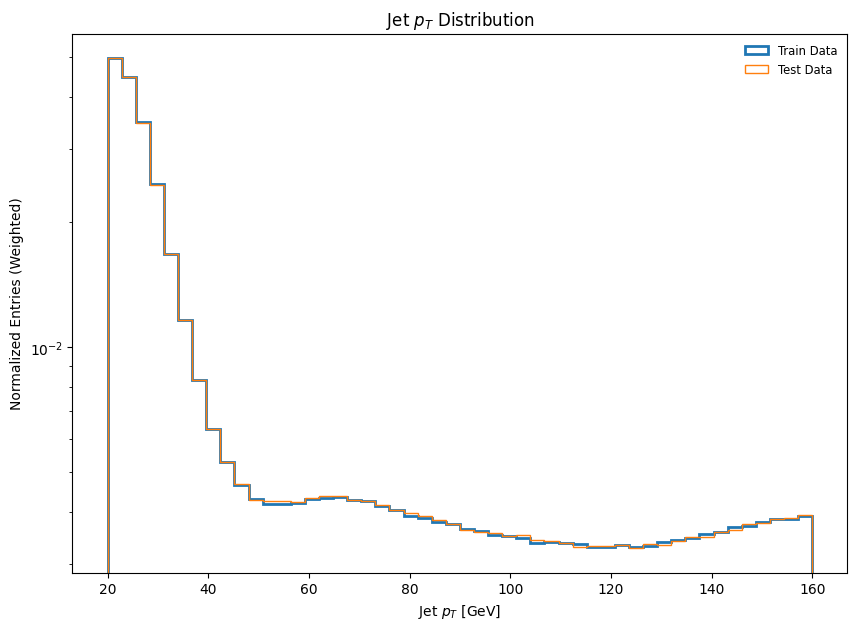

In [14]:
plt.figure(figsize=(10, 7), dpi=100)
plt.hist(train_data["fjet_pt"], weights=None, bins=50, range=(20,160), density=True, linewidth=2, label="Train Data", histtype="step")
plt.hist(test_data["fjet_pt"], weights=None, bins=50, range=(20,160), density=True, linewidth=1, label="Test Data", histtype="step")
plt.xlabel("Jet $p_{T}$ [GeV]")
plt.ylabel("Normalized Entries (Weighted)")

plt.title("Jet $p_{T}$ Distribution")
plt.yscale("log")
plt.legend(loc='upper right', frameon=False, fontsize='small')

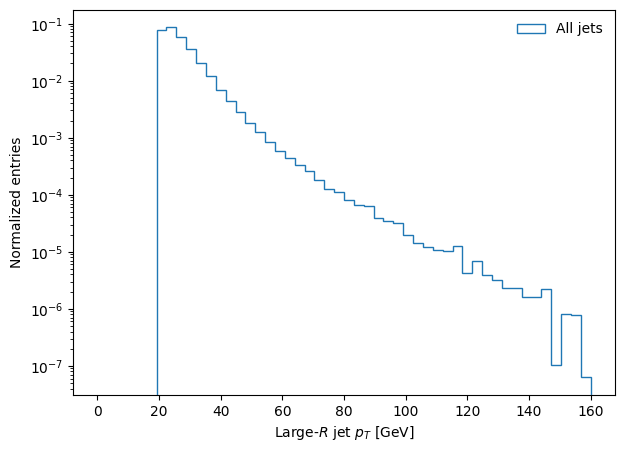

In [15]:


plt.figure(figsize=(7, 5), dpi=100)
plt.hist(data["fjet_pt"], weights=weights, bins=50, range=(0, 160), density=True, histtype="step", label="All jets")
plt.xlabel(r"Large-$R$ jet $p_T$ [GeV]")
plt.ylabel("Normalized entries")
plt.yscale("log")
plt.legend(frameon=False)
plt.show()

In [16]:
def calc_best_discriminant(truth_labels, pqcd, phbb, phcc, ptop, step=0.01):
    # TODO: generalise to arbitrary number of classes
    values = np.arange(step, 1.0, step)
    xx, yy = np.meshgrid(values, values)
    mask = xx + yy < 1

    best_auc = 0
    for fhbb, fhcc in tqdm(np.stack([xx[mask], yy[mask]], axis=-1)):
        denoms = fhbb * phbb + fhcc * phcc + (1 - fhbb - fhcc) * pqcd
        scores = np.log(ptop / denoms)
        auc = roc_auc_score(truth_labels, scores)

        # TODO: is finding the best AUC the right thing to do?
        # TODO: does the ROC curve calculation work correctly if the scores are not normalized to (0,1)?
        # (important for this function and also for the plots later on)
        # TODO: Should use data weights in this calculation!
        if auc > best_auc:
            best_auc = auc
            best_fhbb, best_fhcc = fhbb, fhcc

    return best_auc, best_fhbb, best_fhcc

In [17]:
do_calc_best_discriminant = False
if do_calc_best_discriminant:
    GN3X_best_auc, best_fhbb, best_fhcc = calc_best_discriminant(
        data["labels"],
        data["GN3X_pqcd"],
        data["GN3X_phbb"],
        data["GN3X_phcc"],
        data["GN3X_ptop"],
        step=0.01
    )
    print(f"GN3X best AUC: {GN3X_best_auc:.4f}, fhbb: {best_fhbb:.4f}, fhcc: {best_fhcc:.4f}")
# GN3X best AUC: 0.9349, fhbb: 0.0100, fhcc: 0.0400

In [18]:
if do_calc_best_discriminant:
    fhbb = best_fhbb
    fhcc = best_fhcc
else:
    fhbb = 0.05
    fhcc = 0.05

try:
    if "GN3X_pqcd" in data.fields:
        pqcd = data["GN3X_pqcd"]
    else:
        # Calculate pqcd as sum of components if not present
        pqcd = data["GN3X_pqcdbb"] + data["GN3X_pqcdbx"] + data["GN3X_pqcdcx"] + data["GN3X_pqcdll"]

    denoms = fhbb * data["GN3X_phbb"] + fhcc * data["GN3X_phcc"] + (1 - fhbb - fhcc) * pqcd
    gn3x_scores = np.log(data["GN3X_ptop"] / denoms)
except Exception as e:
    print(f"Error calculating GN3X scores: {e}")
    gn3x_scores = None

Error calculating GN3X scores: no field 'GN3X_pqcdbb' in record with 13 fields


In [47]:
models = {
    "LundNet": {
       "scores": data["fjet_LundNet_FTAG1_score"]
    },
    #"QLundNet": {
    #   "scores": data["fjet_LundNet_FTAG1_score"]
    #},
    "ParT" : {
        "scores": data["parT_score"]
    }
}


# Set tick format for all plots
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'
plt.rcParams['xtick.top'] = True
plt.rcParams['ytick.right'] = True
plt.rcParams['xtick.minor.visible'] = True
plt.rcParams['ytick.minor.visible'] = True
plt.rcParams["axes.formatter.use_mathtext"] = True

# Increase tick mark size
plt.rcParams['xtick.major.size'] = 5
plt.rcParams['xtick.minor.size'] = 3
plt.rcParams['ytick.major.size'] = 5
plt.rcParams['ytick.minor.size'] = 3

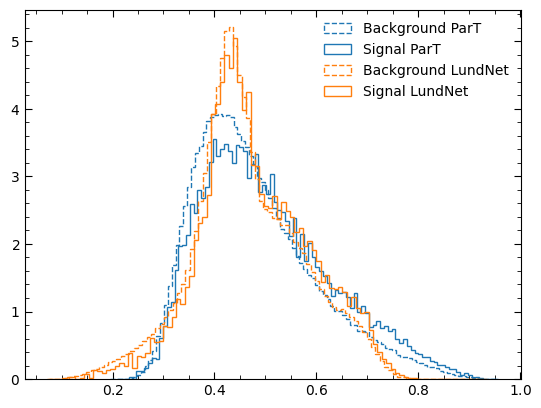

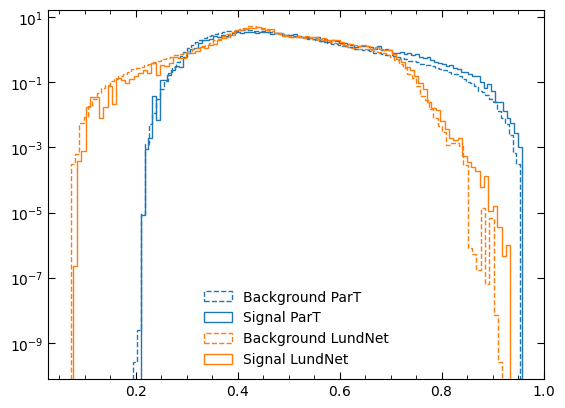

In [48]:
# Extract scores and labels
labels = data["labels"]

hist_params = dict(
    bins = 100,
    # range = (0, 1),
    density = True,
    # alpha = 0.5,
    histtype = "step"
)

selected_models = [ 
                   #"LundNet batch4500rate0.001", 
                   "ParT", 
                   #"LundNet batch4500rate0.0004", 
                   "LundNet"
                   #"QLundNet"
                   ]
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()
for i, model in enumerate(selected_models):
    scores = models[model]["scores"]
    hist_params["color"] = f"C{i}"
    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
    plt.yscale('log')
plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

#selected_models = ["GN3X"]
#for i, model in enumerate(selected_models):
#    scores = models[model]["scores"]
#    hist_params["color"] = f"C{i}"
#    plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#    plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#plt.show()
# for i, model in enumerate(selected_models):
#     scores = models[model]["scores"]
#     hist_params["color"] = f"C{i}"
#     plt.hist(scores[labels==0], weights=weights[labels==0], label="Background "+model, ls="--", **hist_params)
#     plt.hist(scores[labels==1], weights=weights[labels==1], label="Signal "+model,     ls="-",  **hist_params)
#     plt.yscale('log')
# plt.legend(frameon=False)
# plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
plt.show()

In [49]:
# TODO: working point should be calculated differently if weights are used - sum of weights of signal jets with score above threshold should be 50% of total weight of signal jets
# it doesn't make a difference for currently used signal samples because their MC weights are all equal to 1, but this is something to keep in mind for future samples
for model in models:
    # Sort scores corresponding to signal jets
    scores = models[model]["scores"]
    if scores is None:
        print(f"Skipping {model} because scores are None")
        continue

    signal_scores = scores[labels == 1]
    sorted_signal_scores = np.sort(signal_scores)

    # Determine the threshold for 50% signal efficiency
    signal_efficiency = 0.5
    threshold_index = int(signal_efficiency * len(sorted_signal_scores))
    threshold_score = sorted_signal_scores[threshold_index]

    models[model]["threshold_score"] = threshold_score
    print(f"50% signal efficiency threshold for {model}:", threshold_score)

50% signal efficiency threshold for LundNet: 0.5472660660743713
50% signal efficiency threshold for ParT: 0.6455209


In [50]:
var_params = {
    "fjet_m":  {"title": "Large-$R$ jet mass [GeV]",  "bins": 45, "range": (50, 500) },
    "fjet_pt": {"title": "Large-$R$ jet $p_T$ [GeV]", "bins": 30, "range": (0, 3000)},
}

In [51]:
# selected_models = models.keys()  # Use all models for now
# selection = (data["fjet_pt"] > 350) & (np.abs(data["fjet_eta"] < 2))
# plot_signal_after_tagging = False
# plot_errorbars = True
# calc_jsd = False

# plot_params = {
#     "lin": {
#         "yscale": "linear",
#         "ylim": (0, 0.06),
#     },
#     "log": {
#         "yscale": "log",
#         "ylim": (1e-5, 10),
#     }
# }

# for params in plot_params.values():
#     for var in var_params:
#         fig, ax = plt.subplots(figsize=(6.6, 6.6), dpi=200)

#         var_data = data[var]
#         hist_params = dict(
#             bins = var_params[var]["bins"],
#             range = var_params[var]["range"],
#             density = True,
#         )

#         # QCD background: shaded dark gray with black outline
#         bkg_counts = plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], label="QCD background", color="dimgray", alpha=0.7, **hist_params)[0]
#         plt.hist(var_data[(labels==0) & selection], weights=weights[(labels==0) & selection], histtype="step", color="black", linewidth=1.2, **hist_params)
#         # Signal: fill with neutral, light colour
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], label="Signal", color="lightsteelblue", alpha=0.6, **hist_params)
#         plt.hist(var_data[(labels==1) & selection], weights=weights[(labels==1) & selection], histtype="step", color="slategray", linewidth=1.2, **hist_params)

#         for i, model in enumerate(selected_models):
#             tagged_as_signal = models[model]["scores"] > models[model]["threshold_score"]

#             if i !=0 and calc_jsd:
#                 bkg_counts_tagged = np.histogram(
#                     ak.to_numpy(var_data[(labels==0) & tagged_as_signal & selection]),
#                     weights=ak.to_numpy(weights[(labels==0) & tagged_as_signal & selection]),
#                     **hist_params
#                 )[0]
#                 JSD_value = JSD(bkg_counts, bkg_counts_tagged)*100  # TODO: maybe shouldn't be expressed as a percentage
#                 JSD_label = f", JSD = {JSD_value:.2f}%"
#             else:
#                 JSD_label = ""

#             if plot_errorbars:
#                 extra_args = dict(fmt='.')
#                 hist_plot_func = hist_with_errors
#             else:
#                 extra_args = dict(histtype="step", linestyle='-' if i==0 else '--', linewidth=1.5)
#                 hist_plot_func = plt.hist
#             hist_plot_func(
#                 var_data[(labels==0) & tagged_as_signal & selection],
#                 weights=weights[(labels==0) & tagged_as_signal & selection],
#                 label=f"QCD tagged as signal{JSD_label}\n({model})",
#                 **hist_params, **extra_args
#             )
#             if plot_signal_after_tagging:
#                 hist_plot_func(
#                     var_data[(labels==1) & tagged_as_signal & selection],
#                     weights=weights[(labels==1) & tagged_as_signal & selection],
#                     label=f"Signal tagged as signal{JSD_label}\n({model})",
#                     **hist_params, **extra_args
#                 )

#         # Add ATLAS label
#         atlas_label = r"ATLAS"
#         atlas_sim = r"Simulation Internal"
#         atlas_info = r"$\sqrt{s} = 13$ TeV, $top$ tagging"  # TODO: make it autimatically use W or top based on selected config
#         jet_info = r"anti-$k_t$ $R=1.0$ UFO Soft-Drop CS+SK jets"
#         selection_info = r"$\epsilon^{\mathrm{rel}}_{\mathrm{sig}}=50\%,\ p_T > 350$ GeV, $| \eta | < 2.0$" # TODO: make this dynamic based on selection, and for the pT plot show the mass cut
#         text_args = {"transform": ax.transAxes, "va": 'top'}
#         ax.text(0.04, 0.97, atlas_label,    fontsize=12, **text_args, fontweight='bold', style='italic')
#         ax.text(0.20, 0.97, atlas_sim,      fontsize=12, **text_args)
#         ax.text(0.04, 0.92, atlas_info,     fontsize=11, **text_args)
#         ax.text(0.04, 0.87, jet_info,       fontsize=11, **text_args)
#         ax.text(0.04, 0.82, selection_info, fontsize=11, **text_args)

#         plt.xlim(var_params[var]["range"])
#         plt.xlabel(var_params[var]["title"])
#         plt.ylabel("Fraction of jets / 10 GeV")  # TODO: make this dynamic based on bin width, and different for the mass and pT plots
#         plt.yscale(params["yscale"])
#         plt.ylim(params["ylim"])
#         # plt.legend(frameon=False, bbox_to_anchor=(1.04,0.5), loc="center left")
#         plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.45, 0.75))
#         plt.show()

In [52]:
mass = data["fjet_m"]
pt = data["fjet_pt"]
eta = data["fjet_eta"]

mass_cuts = [
    (0, float('inf')),
]
pt_min = 20
pt_max = 160
eta_min = 3.2
eta_max = 4.5
# eta_max = float('inf')

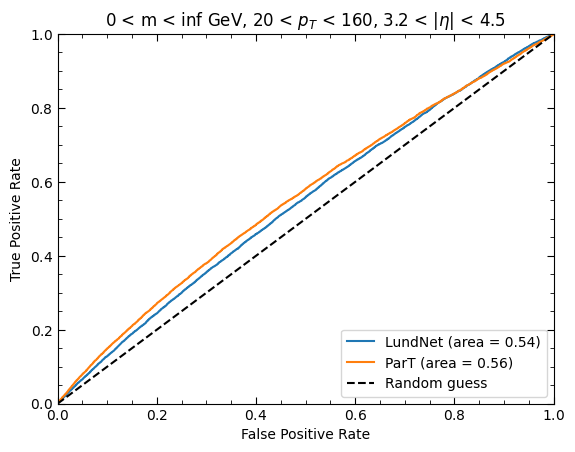

In [53]:
for mass_cut in mass_cuts:
    m_min, m_max = mass_cut
    cuts = (mass > m_min) & (mass < m_max) & (pt > pt_min) & (pt < pt_max) & (np.abs(eta) < eta_max) & (np.abs(eta) > eta_min)
    y_truth_cuts = data["labels"][cuts]
    weights_cuts = weights[cuts]

    for trained_model in models:
        y_pred = models[trained_model]["scores"] if cuts is None else models[trained_model]["scores"][cuts]
        fpr, tpr, thresholds = roc_curve(y_truth_cuts, y_pred, sample_weight=weights_cuts)
        roc_auc = auc(fpr, tpr)

        models[trained_model][f"fpr_{m_min}-{m_max}"] = fpr
        models[trained_model][f"tpr_{m_min}-{m_max}"] = tpr

        plt.plot(fpr, tpr, label=f"{trained_model} (area = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], "--", label="Random guess", color="black")

    plt.title(f"{m_min} < m < {m_max} GeV, {pt_min} < $p_T$ < {pt_max}, {eta_min} < |$\eta$| < {eta_max}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.legend(loc="lower right")
    # plt.legend(bbox_to_anchor=(1.04,0.5), loc="center left")
    plt.show()

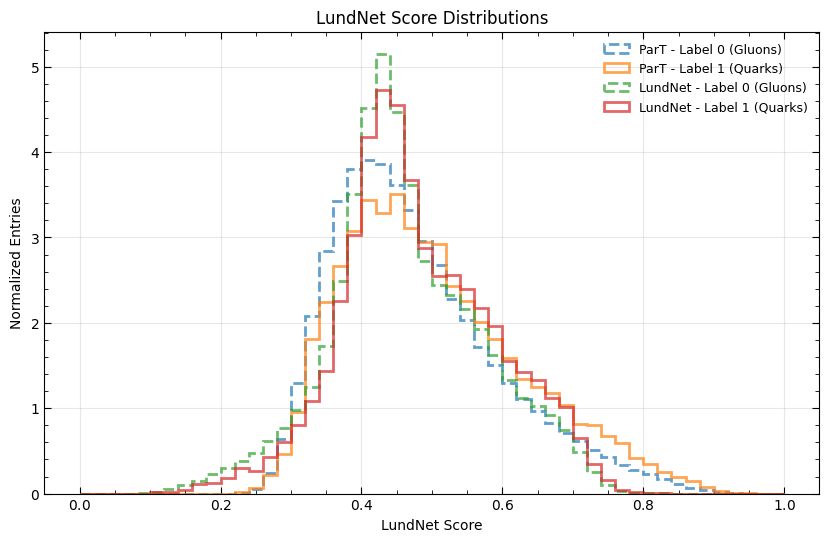

In [60]:
# Extract labels
labels = data["labels"]

# Select which models to plot
selected_models = [
                    "ParT", 
                   "LundNet"
                   #,"LundNet 5% eta 3.2-4.5"
                   ]
# selected_models = list(models.keys())  # Uncomment to plot all models

# Define histogram parameters
hist_params = dict(
    bins=50,
    range=(0, 1),
    density=True,
    histtype="step",
    linewidth=2
)

plt.figure(figsize=(10, 6), dpi=100)

# Plot selected LundNet models
for model_name in selected_models:
    if model_name not in models:
        print(f"Warning: {model_name} not found in models dictionary")
        continue
    
    scores = models[model_name]["scores"]
    
    # Plot label 0 (background/gluons)
    plt.hist(scores[labels == 0], 
             weights=weights[labels == 0],
             label=f"{model_name} - Label 0 (Gluons)",
             linestyle='--',
             alpha=0.7,
             **hist_params)
    
    # Plot label 1 (signal/quarks)
    plt.hist(scores[labels == 1], 
             weights=weights[labels == 1],
             label=f"{model_name} - Label 1 (Quarks)",
             linestyle='-',
             alpha=0.7,
             **hist_params)

plt.xlabel("LundNet Score")
plt.ylabel("Normalized Entries")
plt.title("LundNet Score Distributions")
plt.legend(frameon=False, fontsize=9)
plt.grid(True, alpha=0.3)
plt.show()

/tmp/ipykernel_292595/1559635412.py:37: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=f"{trained_model} (AUC = {roc_auc:.4f})", color=color)
/tmp/ipykernel_292595/1559635412.py:37: RuntimeWarning: divide by zero encountered in divide
  ax1.plot(tpr, 1/fpr, label=f"{trained_model} (AUC = {roc_auc:.4f})", color=color)


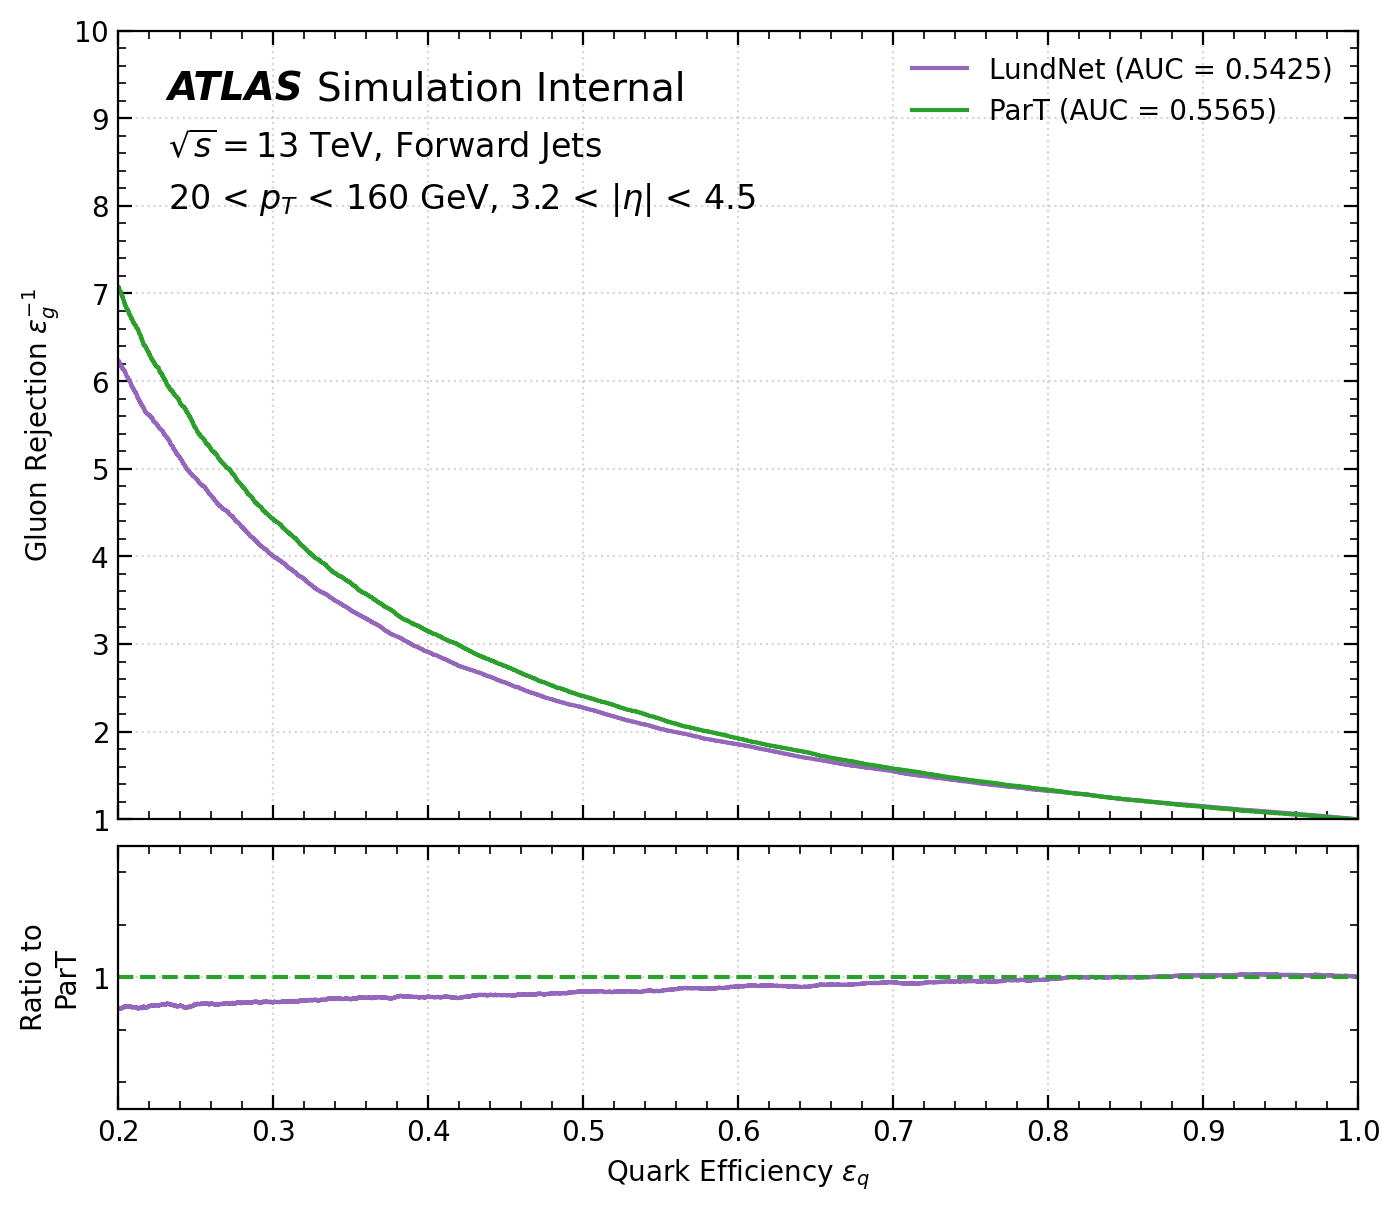

In [93]:
from matplotlib.ticker import MultipleLocator

selected_models = models.keys()  # Use all models for now

show_grid = True

plot_ratio = True
reference_model = "ParT"

model_colors = {
    "ParT": "tab:green",
    "LundNet": "tab:purple"
}
# Fallback colors
default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

for mass_cut in mass_cuts:
    m_min, m_max = mass_cut

    if plot_ratio:
        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 7), gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05}, sharex=True, dpi=200)
    else:
        fig, ax1 = plt.subplots(figsize=(6, 6), dpi=200)

    for i, trained_model in enumerate(selected_models):
        fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
        tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
        
        # Calculate AUC for legend
        roc_auc = auc(fpr, tpr)
        
        if trained_model in model_colors:
            color = model_colors[trained_model]
        else:
             color = default_colors[i % len(default_colors)]
             
        ax1.plot(tpr, 1/fpr, label=f"{trained_model} (AUC = {roc_auc:.4f})", color=color)

    #ax1.set_title(f"{m_min} < m < {m_max} GeV, {pt_min} < $p_T$ < {pt_max}, {eta_min} < |$\eta$| < {eta_max}")
    plt.xlabel(r"Quark Efficiency $\epsilon_q$")
    ax1.set_ylabel(r"Gluon Rejection $\epsilon_g^{-1}$")
    plt.xlim([0.2, 1])
    ax1.set_ylim([1, 1e1]) # Changed to 100 based on typical plots, can adjust if needed
    #ax1.set_yscale("log")
    ax1.legend(frameon=False)
    
    # Grid style
    if show_grid:
        # X-axis: Every 0.1
        ax1.xaxis.set_major_locator(MultipleLocator(0.1))
        
        # Y-axis is Log: default major ticks are powers of 10 (1, 10, 100...) which corresponds to "whole numbers" (integers) in log exponent 
        # or main decades. We enable major grid only.
        ax1.grid(True, which='major', axis='both', ls=":", alpha=0.5)
        ax1.grid(False, which='minor', axis='both') 

    # Add ATLAS Text
    atlas_label = r"ATLAS"
    atlas_sim = r"Simulation Internal"
    atlas_info = r"$\sqrt{s} = 13$ TeV, Forward Jets" 
    
    # Construct selection text
    #mass_text = f"{m_min} < m < {m_max} GeV" if m_max != float('inf') else f"m > {m_min} GeV"
    pt_text = f"{pt_min} < $p_T$ < {pt_max} GeV"
    eta_text = f"{eta_min} < $|\eta|$ < {eta_max}"
    selection_info = f"{pt_text}, {eta_text}"

    text_args = {"transform": ax1.transAxes, "va": 'top'}
    ax1.text(0.04, 0.95, atlas_label,    fontsize=14, **text_args, fontweight='bold', style='italic')
    ax1.text(0.16, 0.95, atlas_sim,      fontsize=14, **text_args)
    ax1.text(0.04, 0.88, atlas_info,     fontsize=12, **text_args)
    ax1.text(0.04, 0.81, selection_info, fontsize=12, **text_args)


    # Ratio subplot
    if plot_ratio:
        ref_fpr = models[reference_model][f"fpr_{m_min}-{m_max}"]
        ref_tpr = models[reference_model][f"tpr_{m_min}-{m_max}"]
        # Avoid division by zero in ref_rej
        ref_mask = ref_fpr > 0
        ref_tpr = ref_tpr[ref_mask]
        ref_fpr = ref_fpr[ref_mask]

        for i, trained_model in enumerate(selected_models):
            if trained_model in model_colors:
                color = model_colors[trained_model]
            else:
                color = default_colors[i % len(default_colors)]
                
            if trained_model == reference_model:
                ax2.axhline(1, color=color, ls="--") # Reference at 1, now using green for ParT
                continue
                
            fpr = models[trained_model][f"fpr_{m_min}-{m_max}"]
            tpr = models[trained_model][f"tpr_{m_min}-{m_max}"]
            
            # Interpolate to reference tpr points
            
            try:
                # Interpolate model rejection at reference TPR points
                model_rej = np.interp(ref_tpr, tpr, 1/np.maximum(fpr, 1e-10), left=np.nan, right=np.nan)
                ref_rej = 1/np.maximum(ref_fpr, 1e-10)
                
                ratio = model_rej / ref_rej
                ax2.plot(ref_tpr, ratio, label=f"{trained_model} / {reference_model}", color=color)
            except Exception as e:
                print(f"Error calculating ratio for {trained_model}: {e}")

        ax2.set_ylabel(f"Ratio to\n{reference_model}")
        ax2.set_ylim([0.5, 1.5])
        if show_grid:
             ax2.xaxis.set_major_locator(MultipleLocator(0.1))
             # For ratio, "whole number" is just 1.0 (since range is 0.5-1.5)
             ax2.yaxis.set_major_locator(MultipleLocator(1.0))
             ax2.grid(True, which='major', axis='both', ls=":", alpha=0.5)

    plt.show()

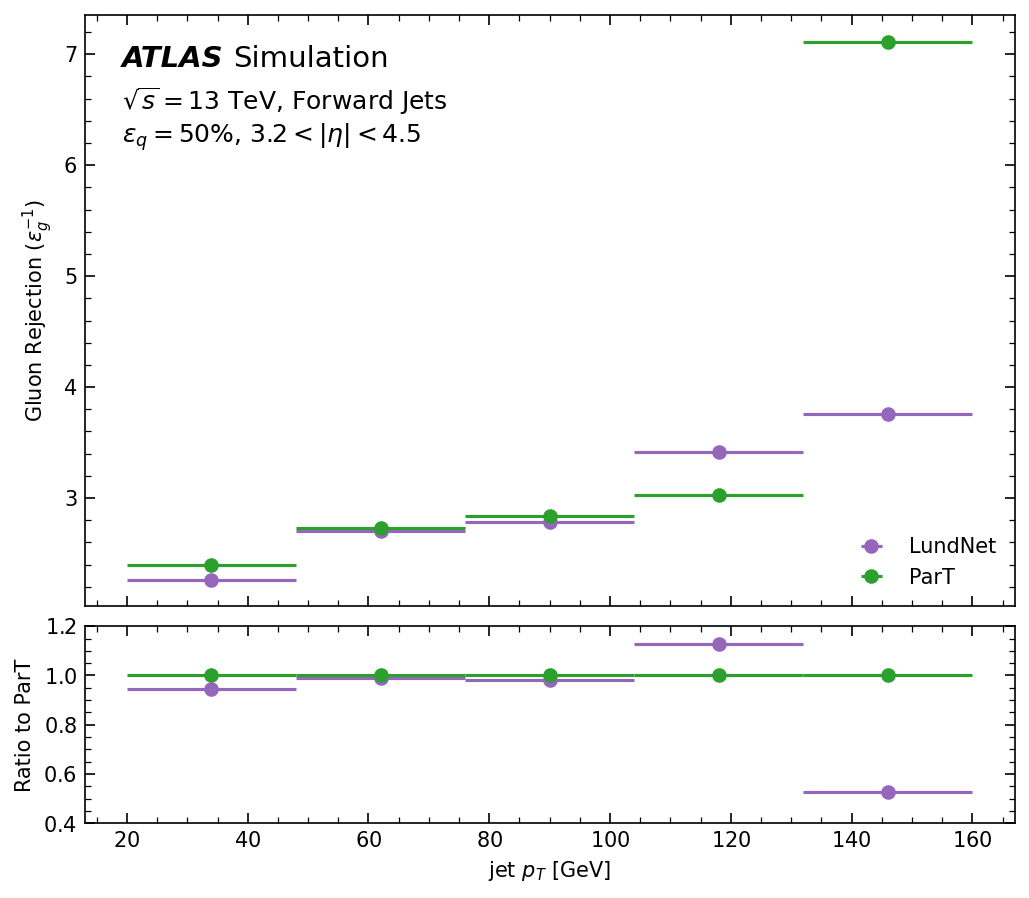

In [79]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, reference_model="ParT"):
    """
    Graphs the gluon rejection (1/epsilon_g) at a fixed quark efficiency (epsilon_q) as a function of jet pT.
    Includes a ratio plot comparing to the reference model.
    """
    pt = data["fjet_pt"]
    labels = data["labels"]
    
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    fig, (ax0, ax1) = plt.subplots(2, 1, figsize=(8, 7), dpi=150, sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    
    # Color mapping
    # DeParT (ParT) -> Green ("tab:green")
    # FC (LundNet) -> Purple ("tab:purple")
    model_colors = {
        "ParT": "tab:green",
        "LundNet": "tab:purple"
    }
    # Fallback cycle
    default_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
    
    model_rejections = {}
    
    for i, model_name in enumerate(models):
        scores = models[model_name]["scores"]
        rejections = []
        
        # Determine color
        if model_name in model_colors:
            color = model_colors[model_name]
        else:
            color = default_colors[i % len(default_colors)]
        
        for i_bin in range(len(pt_bins)-1):
            p_min, p_max = pt_bins[i_bin], pt_bins[i_bin+1]
            mask = (pt >= p_min) & (pt < p_max)
            
            if np.sum(mask) < 10: 
                rejections.append(np.nan)
                continue
            
            y_true = ak.to_numpy(labels[mask])
            y_score = ak.to_numpy(scores[mask])
            w = ak.to_numpy(weights[mask])
            
            if len(np.unique(y_true)) < 2: 
                rejections.append(np.nan)
                continue
            
            # Split into signal and background
            sig_mask = (y_true == 1)
            bkg_mask = (y_true == 0)
            
            s_scores = y_score[sig_mask]
            s_weights = w[sig_mask]
            b_scores = y_score[bkg_mask]
            b_weights = w[bkg_mask]
            
            if len(s_scores) == 0 or len(b_scores) == 0: 
                rejections.append(np.nan)
                continue
            
            # 1. Determine Threshold from Signal
            sorter = np.argsort(s_scores)
            s_scores_sorted = s_scores[sorter]
            s_weights_sorted = s_weights[sorter]
            
            cum_w = np.cumsum(s_weights_sorted)
            total_s_w = cum_w[-1]
            
            target_w = total_s_w * (1 - signal_efficiency)
            idx = np.searchsorted(cum_w, target_w)
            threshold = s_scores_sorted[min(idx, len(s_scores_sorted)-1)]
            
            # 2. Calculate Background Efficiency (FPR)
            pass_mask = b_scores > threshold
            
            W_total = np.sum(b_weights)
            W_pass = np.sum(b_weights[pass_mask])
            
            if W_pass == 0:
                rejections.append(np.nan) 
                continue 
                
            epsilon_g = W_pass / W_total
            
            R = 1.0 / epsilon_g
            
            rejections.append(R)
            
        rejections = np.array(rejections)
        
        # Store for ratio
        model_rejections[model_name] = rejections

        # Plot valid points
        mask = ~np.isnan(rejections)
        if np.sum(mask) > 0:
             ax0.errorbar(bin_centers[mask], rejections[mask], xerr=bin_half_widths[mask], 
                          fmt='o', label=model_name, capsize=0, elinewidth=1.5, color=color)
        
    ax0.set_ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    ax0.legend(frameon=False)
    # ax0.set_title(f"Rejection vs $p_T$ (Flat $\epsilon_q$ = {signal_efficiency})")
    
    # Add ATLAS Text
    atlas_label = r"ATLAS"
    atlas_sim = r"Simulation"
    atlas_info = r"$\sqrt{s} = 13$ TeV, Forward Jets" 
    selection_info = f"$\epsilon_q = {int(signal_efficiency*100)}\%$, $3.2 < |\eta| < 4.5$"
    
    text_args = {"transform": ax0.transAxes, "va": 'top'}
    ax0.text(0.04, 0.95, atlas_label,    fontsize=14, **text_args, fontweight='bold', style='italic')
    ax0.text(0.16, 0.95, atlas_sim,      fontsize=14, **text_args)
    ax0.text(0.04, 0.88, atlas_info,     fontsize=12, **text_args)
    ax0.text(0.04, 0.82, selection_info, fontsize=12, **text_args)


    # Lower panel: Ratio
    if reference_model in model_rejections:
        ref_rej = model_rejections[reference_model]
        
        for i, model_name in enumerate(models):
            # Determine color
            if model_name in model_colors:
                color = model_colors[model_name]
            else:
                color = default_colors[i % len(default_colors)]
            
            if model_name not in model_rejections: continue
            
            # Calculate ratio
            rej = model_rejections[model_name]
            # Avoid division by zero or NaN
            with np.errstate(divide='ignore', invalid='ignore'):
                ratio = rej / ref_rej
            
            # Plot ratio
            mask = ~np.isnan(ratio)
            if np.sum(mask) > 0:
                ax1.errorbar(bin_centers[mask], ratio[mask], xerr=bin_half_widths[mask], 
                             fmt='o', capsize=0, elinewidth=1.5, color=color) 
                
    #ax1.axhline(1, color='gray', linestyle='--', alpha=0.5)
    
    ax1.set_ylabel(f"Ratio to {reference_model}")
    ax1.set_xlabel(r"jet $p_T$ [GeV]")
    ax1.set_ylim(0.4, 1.2)
    plt.show()

# Define pT bins covering the range of interest (20 to 160 GeV)
pt_bins = np.linspace(20, 160, 6)

# Call the function
plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, reference_model="ParT")

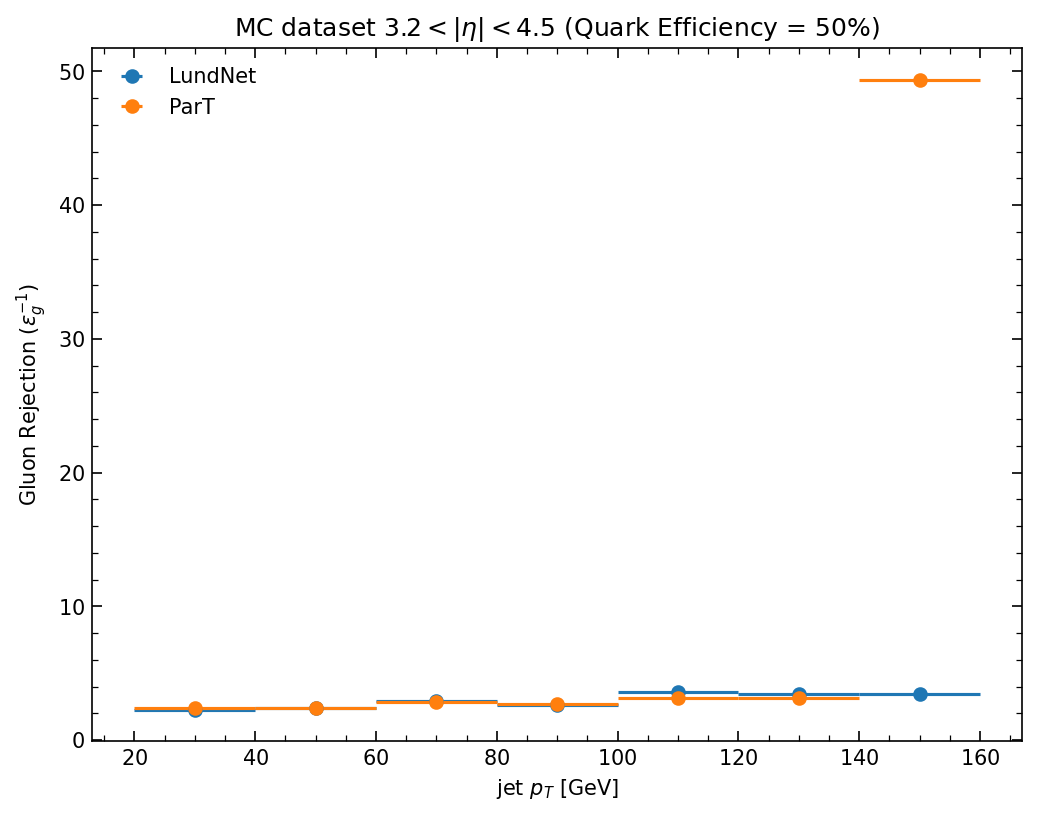

In [63]:
def plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, model_name_map=None):
    """
    Graphs the gluon rejection (1/epsilon_g) at a fixed quark efficiency (epsilon_q) as a function of jet pT,
    with error bars derived from background statistics.
    
    Methodology:
    1. In each pT bin, determine the score threshold x_WP such that the weighted fraction of signal events 
       with score > x_WP is equal to `signal_efficiency`.
    2. Calculate the weighted fraction of background events passing this threshold (epsilon_g).
    3. Calculate rejection R = 1 / epsilon_g.
    4. Calculate statistical uncertainty on R using error propagation for weighted binomial efficiency.
    """
    pt = data["fjet_pt"]
    labels = data["labels"]
    
    bin_centers = (pt_bins[:-1] + pt_bins[1:]) / 2
    bin_half_widths = (pt_bins[1:] - pt_bins[:-1]) / 2
    
    plt.figure(figsize=(8, 6), dpi=150)
    
    for model_name in models:
        scores = models[model_name]["scores"]
        rejections = []
        errors = []
        valid_centers = []
        valid_xerr = []
        
        # Determine label using map if provided
        label_name = model_name
        if model_name_map and model_name in model_name_map:
            label_name = model_name_map[model_name]
        
        for i in range(len(pt_bins)-1):
            p_min, p_max = pt_bins[i], pt_bins[i+1]
            mask = (pt >= p_min) & (pt < p_max)
            
            if np.sum(mask) < 10: continue
            
            y_true = ak.to_numpy(labels[mask])
            y_score = ak.to_numpy(scores[mask])
            w = ak.to_numpy(weights[mask])
            
            if len(np.unique(y_true)) < 2: continue
            
            # Split into signal and background
            sig_mask = (y_true == 1)
            bkg_mask = (y_true == 0)
            
            s_scores = y_score[sig_mask]
            s_weights = w[sig_mask]
            b_scores = y_score[bkg_mask]
            b_weights = w[bkg_mask]
            
            if len(s_scores) == 0 or len(b_scores) == 0: continue
            
            # 1. Determine Threshold from Signal
            # We want to keep 'signal_efficiency' fraction of signal events (highest scores)
            # Sort signal scores
            sorter = np.argsort(s_scores)
            s_scores_sorted = s_scores[sorter]
            s_weights_sorted = s_weights[sorter]
            
            cum_w = np.cumsum(s_weights_sorted)
            total_s_w = cum_w[-1]
            
            # Threshold is the score where (1 - signal_efficiency) of weight is below it
            # e.g. 50% eff -> 50% below. 80% eff -> 20% below.
            target_w = total_s_w * (1 - signal_efficiency)
            idx = np.searchsorted(cum_w, target_w)
            threshold = s_scores_sorted[min(idx, len(s_scores_sorted)-1)]
            
            # 2. Calculate Background Efficiency (FPR) and Error
            # Pass = score > threshold
            pass_mask = b_scores > threshold
            
            W_total = np.sum(b_weights)
            W_pass = np.sum(b_weights[pass_mask])
            
            if W_pass == 0:
                continue # Infinite rejection
                
            epsilon_g = W_pass / W_total
            
            # Error propagation for weighted efficiency
            # var(eps) = (1/W_tot^2) * [ (1-eps)^2 * sum(w_pass^2) + eps^2 * sum(w_fail^2) ]
            sw2_pass = np.sum(b_weights[pass_mask]**2)
            sw2_fail = np.sum(b_weights[~pass_mask]**2)
            
            var_epsilon = (1.0 / W_total**2) * ( (1 - epsilon_g)**2 * sw2_pass + epsilon_g**2 * sw2_fail )
            sigma_epsilon = np.sqrt(var_epsilon)
            
            # Rejection R = 1 / epsilon
            R = 1.0 / epsilon_g
            # sigma_R = R^2 * sigma_epsilon
            sigma_R = (R**2) * sigma_epsilon
            
            rejections.append(R)
            errors.append(sigma_R)
            valid_centers.append(bin_centers[i])
            valid_xerr.append(bin_half_widths[i])
            
        plt.errorbar(valid_centers, rejections, xerr=valid_xerr, fmt='o', label=label_name, capsize=0, elinewidth=1.5)
        
    plt.xlabel(r"jet $p_T$ [GeV]")
    plt.ylabel(r"Gluon Rejection ($\epsilon_{g}^{-1}$)")
    #plt.xscale("log")
    plt.legend(frameon=False)
    #plt.grid(True, which="both", ls="--", alpha=0.5)
    plt.title(r"MC dataset $3.2 < |\eta| < 4.5$ (Quark Efficiency = 50%)")
    plt.show()

# Define pT bins covering the range of interest (20 to 160 GeV)
pt_bins = np.linspace(20, 160, 8)

# Define map for cleaner legend labels (optional)
model_name_map = {
     "parT": r"ParT",
     "LundNet 20% eta 3.2-4.5": r"LundNet (20% data)",
     "LundNet 5% eta 3.2-4.5": r"LundNet (5% data)"
}

# Call the function
plot_gluon_rejection_vs_pt(models, data, weights, pt_bins, signal_efficiency=0.5, model_name_map=model_name_map)

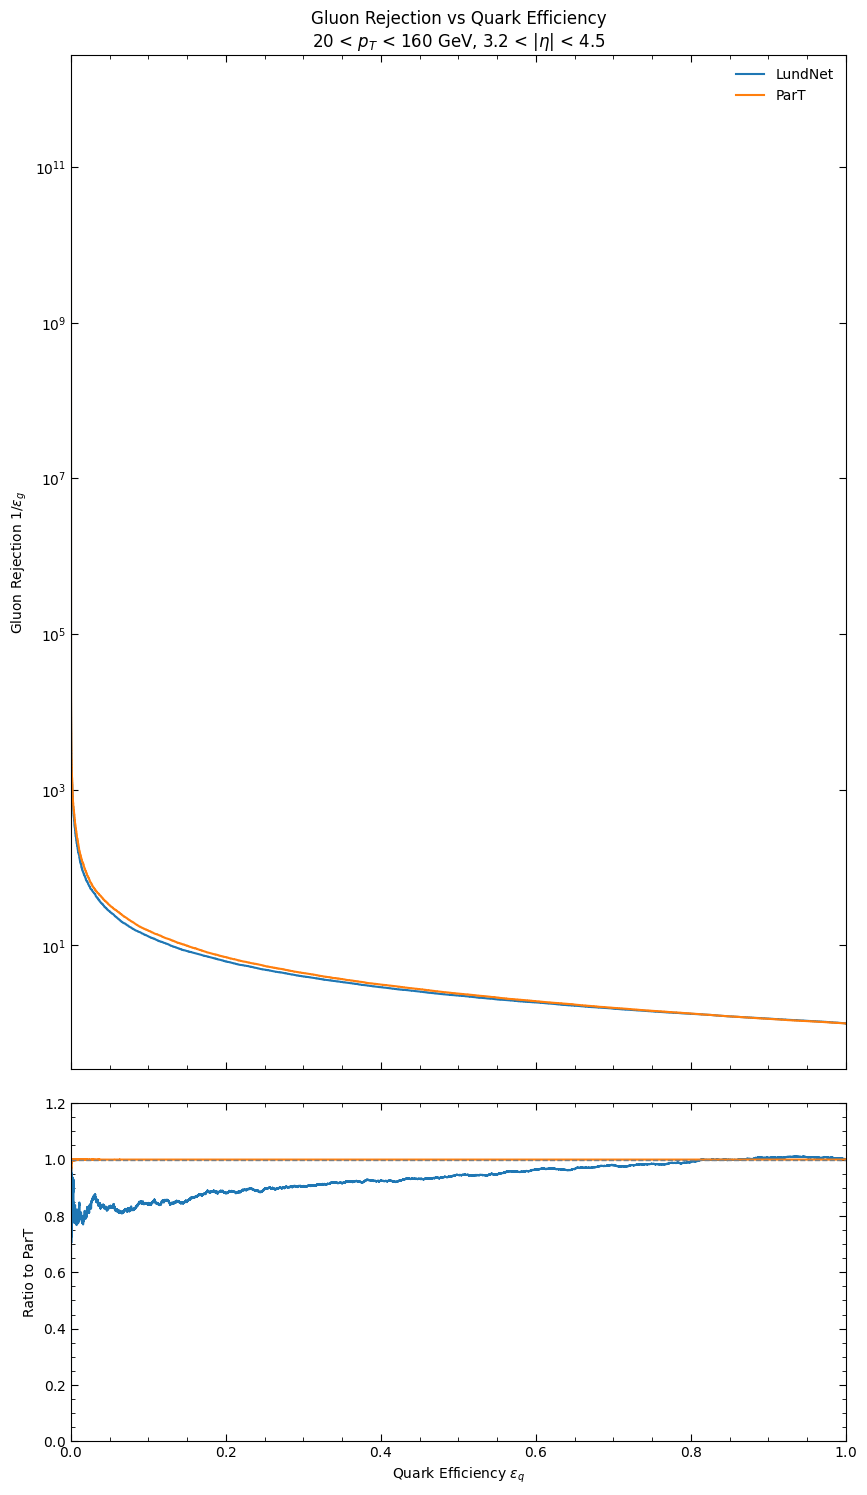

In [64]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

# Use variables if they exist, otherwise set defaults
try:
    my_mass_cuts = mass_cuts
    my_pt_min = pt_min
    my_pt_max = pt_max
    my_eta_min = eta_min
    my_eta_max = eta_max
except NameError:
    my_mass_cuts = [(0, float('inf'))]
    my_pt_min = 20
    my_pt_max = 160
    my_eta_min = 3.2
    my_eta_max = 4.5

reference_model = "ParT"

for m_min, m_max in my_mass_cuts:
    # Filter data based on cuts
    mask_sel = (data["fjet_m"] > m_min) & (data["fjet_m"] < m_max) & \
               (data["fjet_pt"] > my_pt_min) & (data["fjet_pt"] < my_pt_max) & \
               (np.abs(data["fjet_eta"]) < my_eta_max) & (np.abs(data["fjet_eta"]) > my_eta_min)
    
    if np.sum(mask_sel) == 0:
        continue

    y_true_sel = data["labels"][mask_sel]
    weights_sel = weights[mask_sel]
    
    # Store results for plotting
    results = {}

    for model_name in models:
        val = models[model_name]
        if "scores" not in val or val["scores"] is None:
            continue
            
        scores_sel = val["scores"][mask_sel]
        
        # Calculate ROC curve
        fpr, tpr, _ = roc_curve(y_true_sel, scores_sel, sample_weight=weights_sel)
        
        # Calculate Rejection (1/FPR)
        with np.errstate(divide='ignore'):
            rejection = 1.0 / fpr
            
        results[model_name] = {"tpr": tpr, "rejection": rejection}

    # Setup plot with ratio panel
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 18), gridspec_kw={'height_ratios': [3, 1]}, sharex=True, dpi=100)
    
    # Check if reference model exists
    if reference_model in results:
        ref_tpr = results[reference_model]["tpr"]
        ref_rej = results[reference_model]["rejection"]
    else:
        print(f"Warning: Reference model {reference_model} not found.")
        ref_tpr = None

    for model_name, res in results.items():
        tpr = res["tpr"]
        rejection = res["rejection"]
        
        # Top Panel: Rejection
        ax1.plot(tpr, rejection, label=model_name)
        
        # Bottom Panel: Ratio
        if ref_tpr is not None:
             # Interpolate current model rejection to reference tpr points
             # We want ratio of Rejection(model) / Rejection(ref) at same Efficiency (TPR)
             rej_interp = np.interp(ref_tpr, tpr, rejection, left=np.nan, right=np.nan)
             
             # Avoid division by zero or invalid values
             with np.errstate(divide='ignore', invalid='ignore'):
                ratio = rej_interp / ref_rej
             
             ax2.plot(ref_tpr, ratio, label=f"{model_name}/{reference_model}")

    # Styling Top Panel
    ax1.set_yscale('log')
    ax1.set_ylabel(r"Gluon Rejection $1/\epsilon_g$")
    ax1.legend(frameon=False)
    #ax1.grid(True, which="both", ls="--", alpha=0.5)
    
    title_text = f"Gluon Rejection vs Quark Efficiency\n"
    title_text += f"{my_pt_min} < $p_T$ < {my_pt_max} GeV, {my_eta_min} < |$\eta$| < {my_eta_max}"
    ax1.set_title(title_text)
    
    # Styling Bottom Panel
    ax2.set_xlabel(r"Quark Efficiency $\epsilon_q$")
    ax2.set_ylabel(f"Ratio to {reference_model}")
    ax2.set_ylim(0, 1.2) 
    #ax2.grid(True, which="both", ls="--", alpha=0.5)
    ax2.axhline(1, color='gray', linestyle='--', linewidth=1)

    plt.xlim(0, 1.0)
    plt.subplots_adjust(hspace=0.05)
    plt.show()

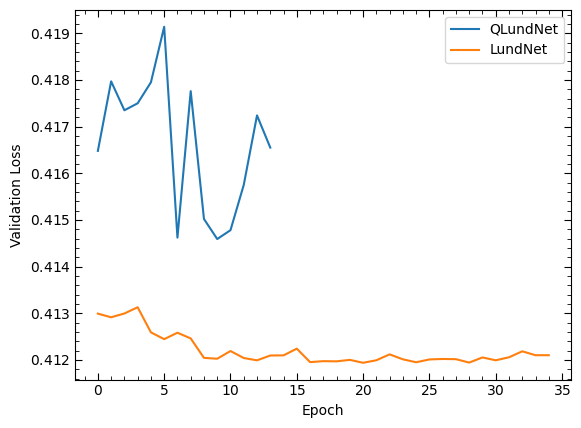

In [65]:
qlundnet_loss_val = [0.41648, 0.41797,0.41735, 0.41750, 0.41795, 0.41914, 0.41462, 0.41776, 0.41502, 0.41459, 0.41478, 0.41575, 0.41724, 0.41655]
lundnet_loss_val = [0.4129909157236111,
0.412912640126844,0.41299381554917447,0.4131274524192639,0.41258927388792505,0.41244363015042207,0.41258136056443584,0.4124595738218904,0.41204237069897925,0.41202413088829504,0.41218894806604495,0.4120392087675121
,0.4119898578604032,0.41209300996601994,0.4120961304138897,0.4122401176394598,0.4119514414584926,0.4119720525722388,0.4119679033509491,0.4119996510229953,0.4119371229536897,0.4119912351194437,0.4121175700074156
,0.41201123221110036,0.4119481488726125,0.4120089445985466,0.4120188089608233,0.41201436199305813,0.4119416182385875,0.412051447791244,0.4119903276894332,0.4120549693989952,0.41218253293426127,0.4120993487622214
,0.4120995069396965]

plt.plot(qlundnet_loss_val, label="QLundNet")
plt.plot(lundnet_loss_val, label="LundNet")
plt.xlabel("Epoch")

plt.ylabel("Validation Loss")
plt.legend()
